In [ ]:
pip install missingno

# Step One: Import datasets

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df1 = pd.read_csv("/content/Insertion_Depth_Dataset.csv")
df2 = pd.read_csv("/content/Insertion_Depth_Dataset_missing_values.csv")




# Step Two: Missing Data Visualization

Saving Insertion_Depth_Dataset_missing_values.csv to Insertion_Depth_Dataset_missing_values (4).csv


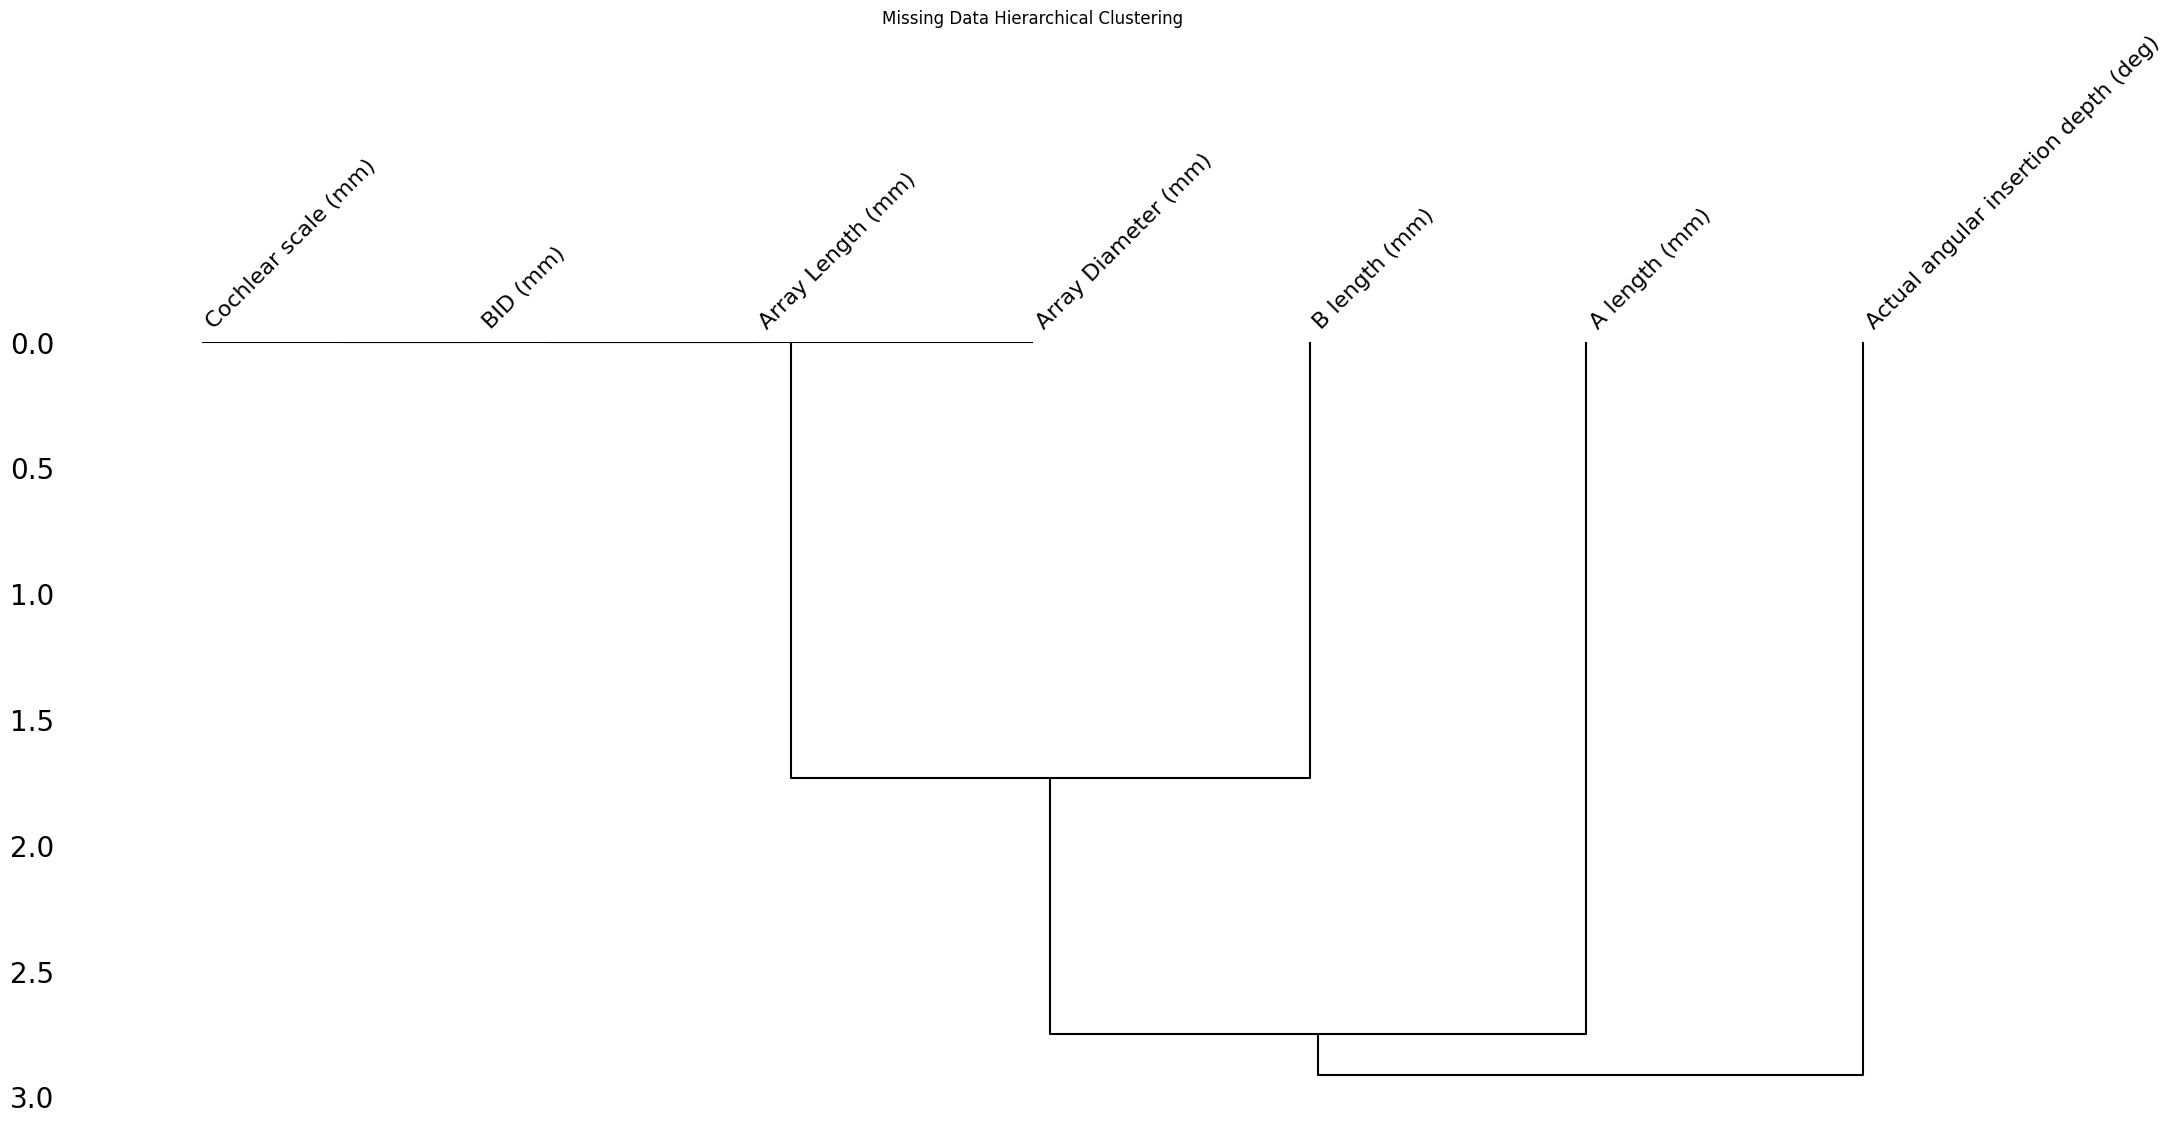

In [ ]:
#  Dendrogram
from google.colab import files
uploaded = files.upload()

# Pulling data set
df2 = pd.read_csv("/content/Insertion_Depth_Dataset_missing_values.csv")

# Creating the Dendrogram
msno.dendrogram(df2)
plt.title("Missing Data Hierarchical Clustering")
plt.show()


Saving Insertion_Depth_Dataset_missing_values.csv to Insertion_Depth_Dataset_missing_values (6).csv


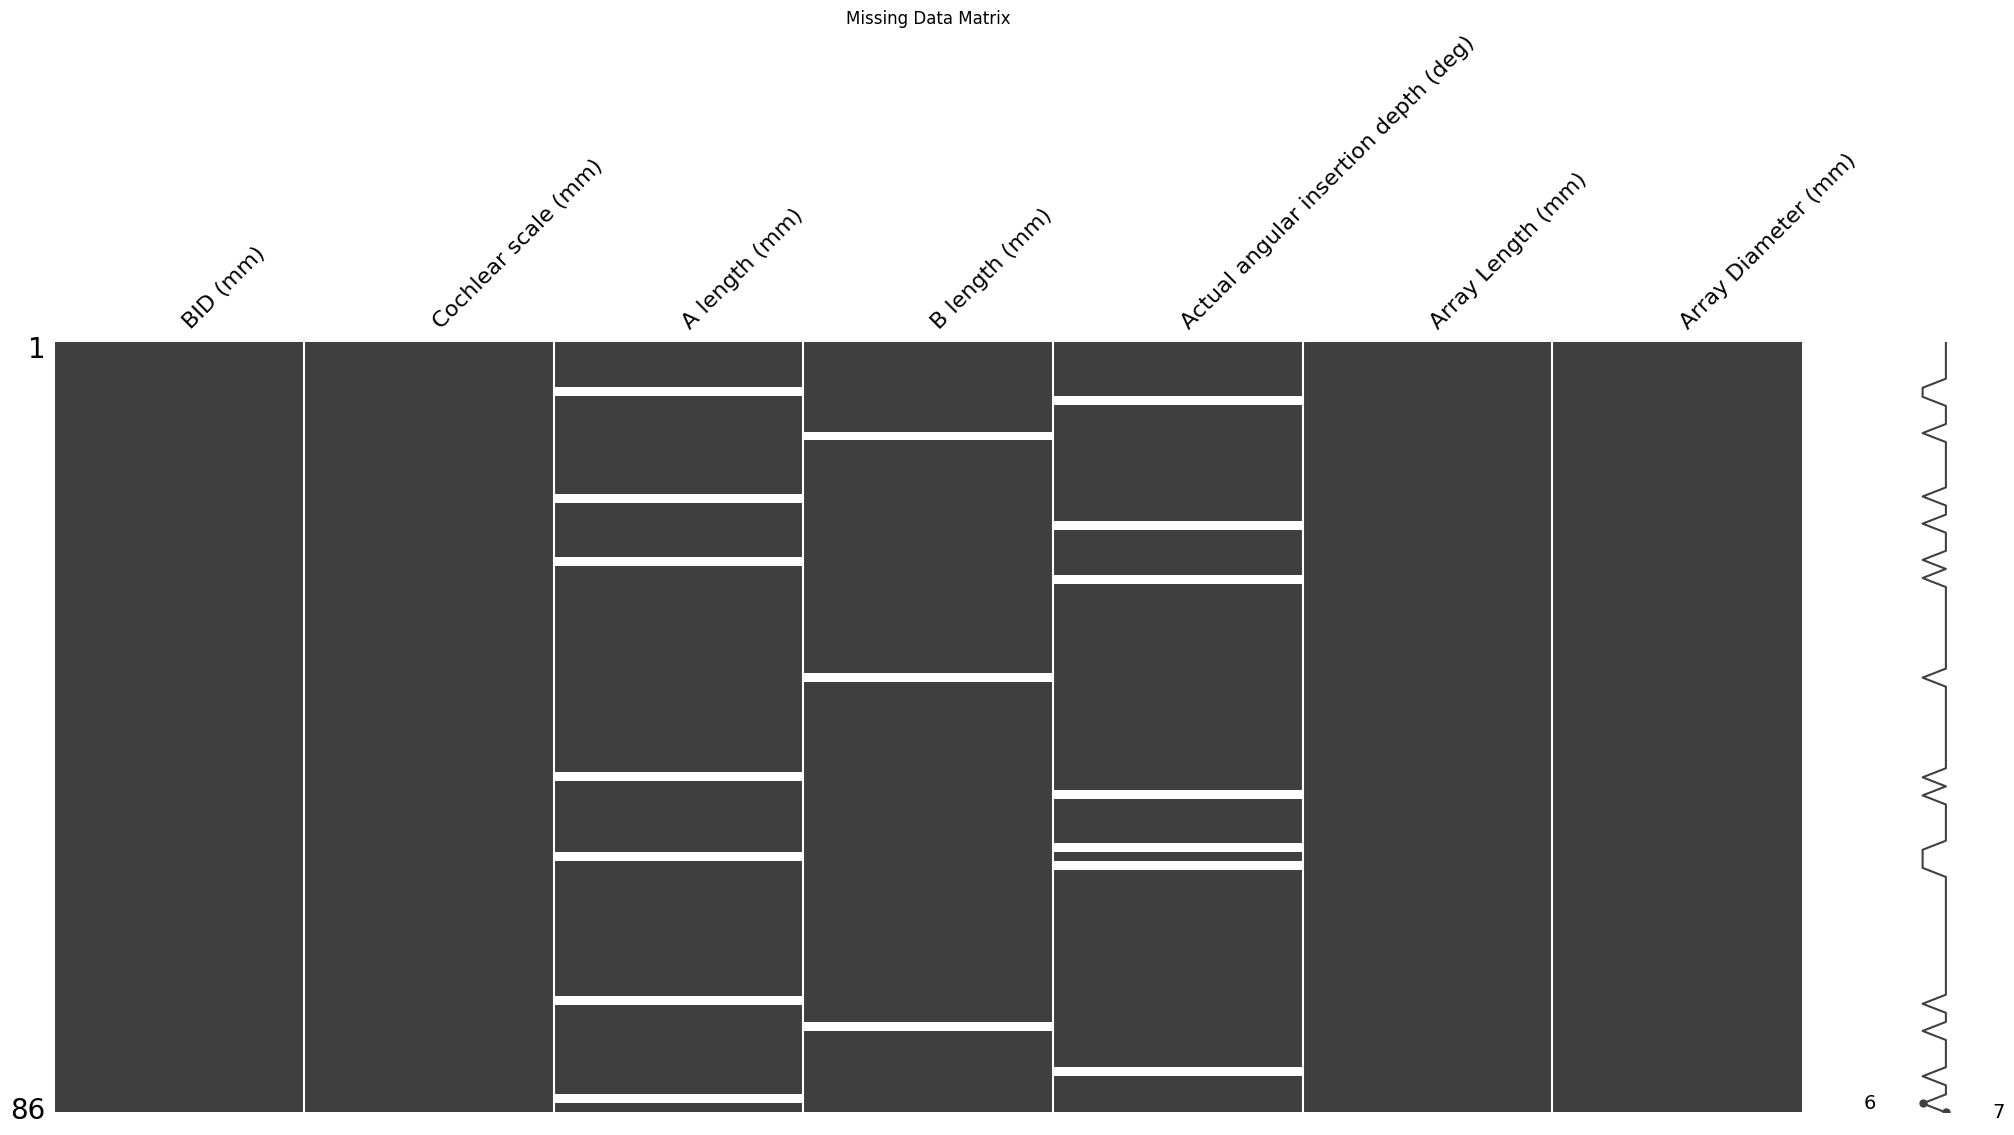

In [ ]:
# Matrix

from google.colab import files
uploaded = files.upload()

df2 = pd.read_csv("/content/Insertion_Depth_Dataset_missing_values.csv")

# Creating the Matrix
msno.matrix(df2)
plt.title("Missing Data Matrix")
plt.show()

Saving Insertion_Depth_Dataset_missing_values.csv to Insertion_Depth_Dataset_missing_values (5).csv


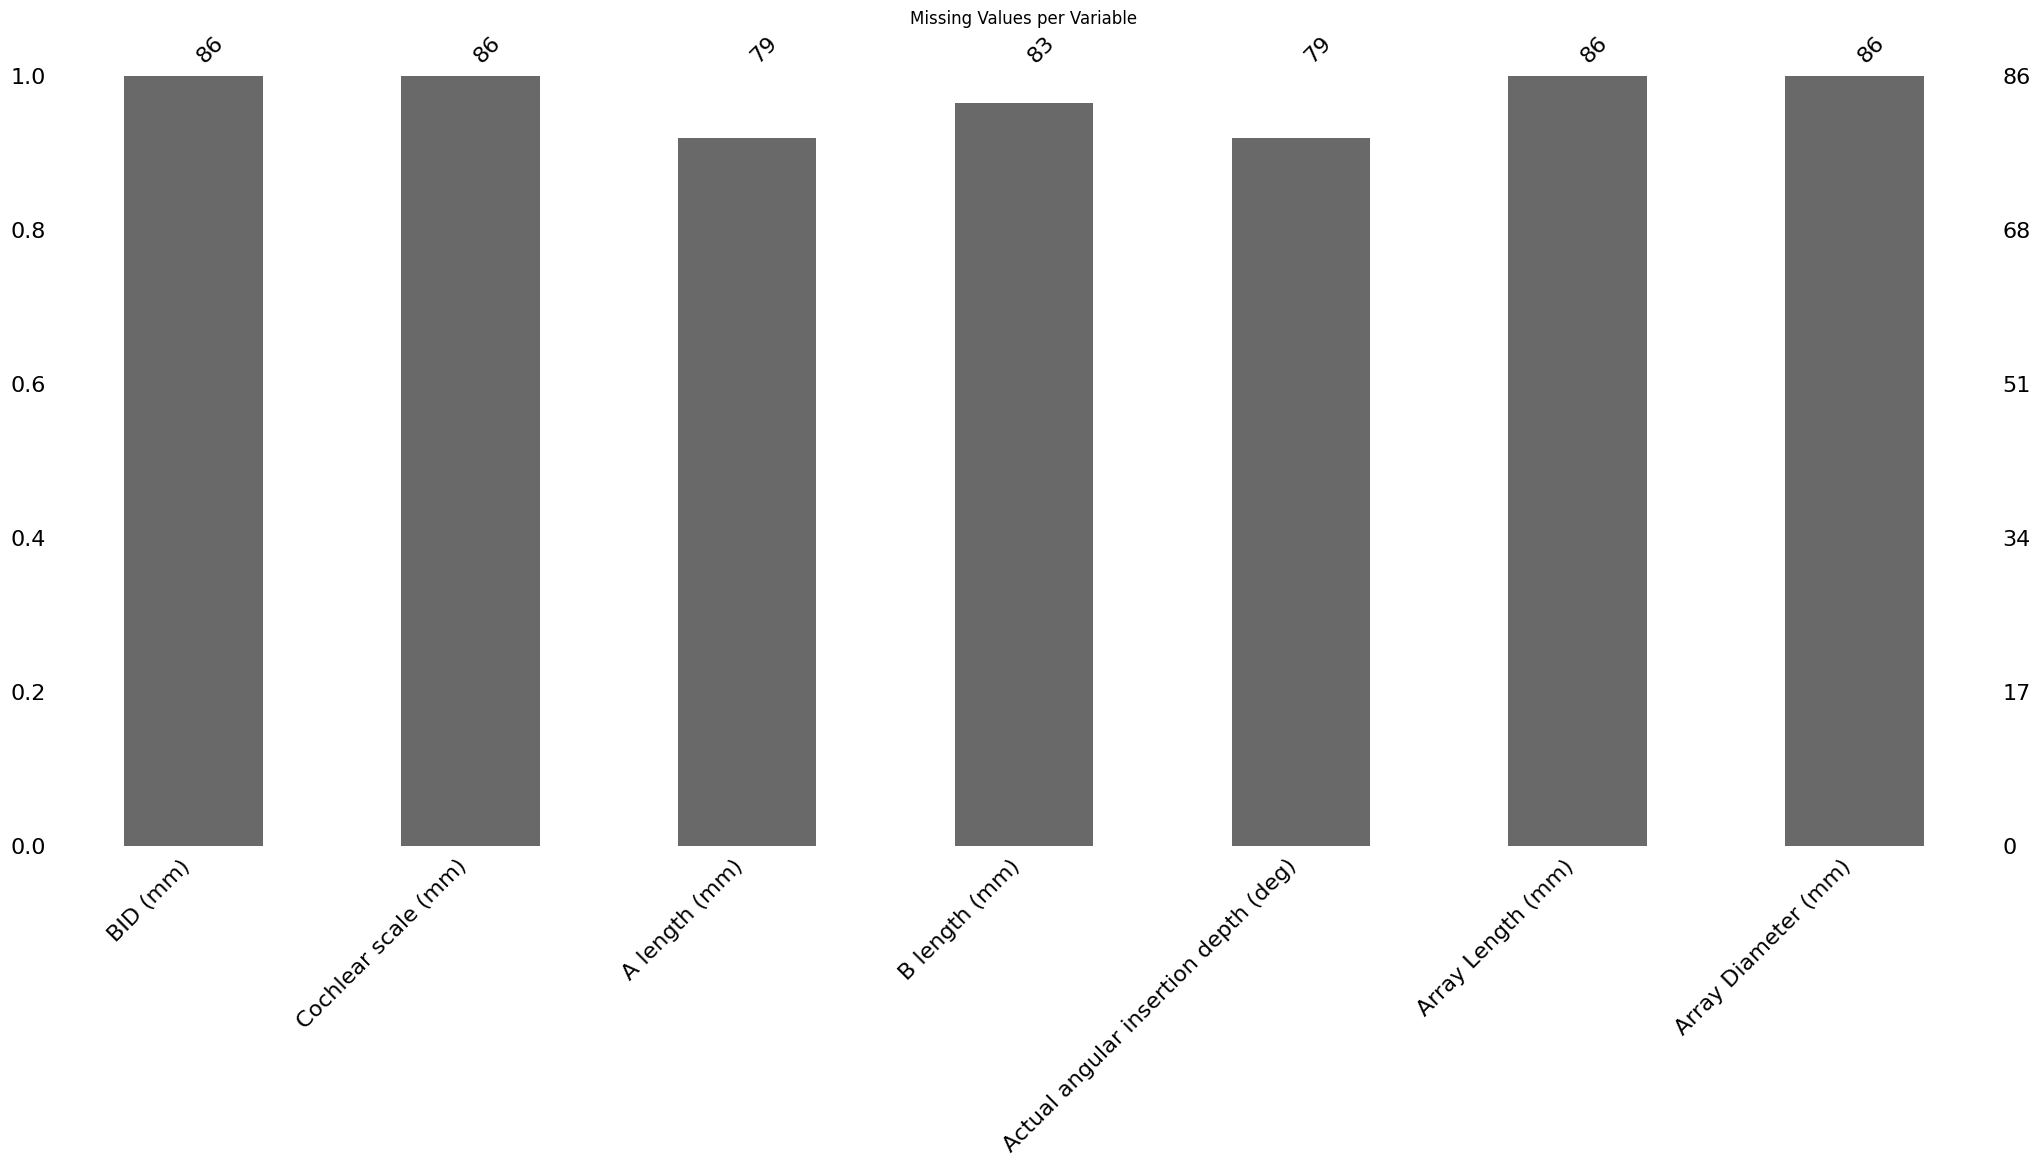

In [ ]:
#Bar Chart

from google.colab import files
uploaded = files.upload()


df2 = pd.read_csv("/content/Insertion_Depth_Dataset_missing_values.csv")

# Creating the Bar Chart
msno.bar(df2)
plt.title("Missing Values per Variable")
plt.show()



Saving Insertion_Depth_Dataset_missing_values.csv to Insertion_Depth_Dataset_missing_values (7).csv


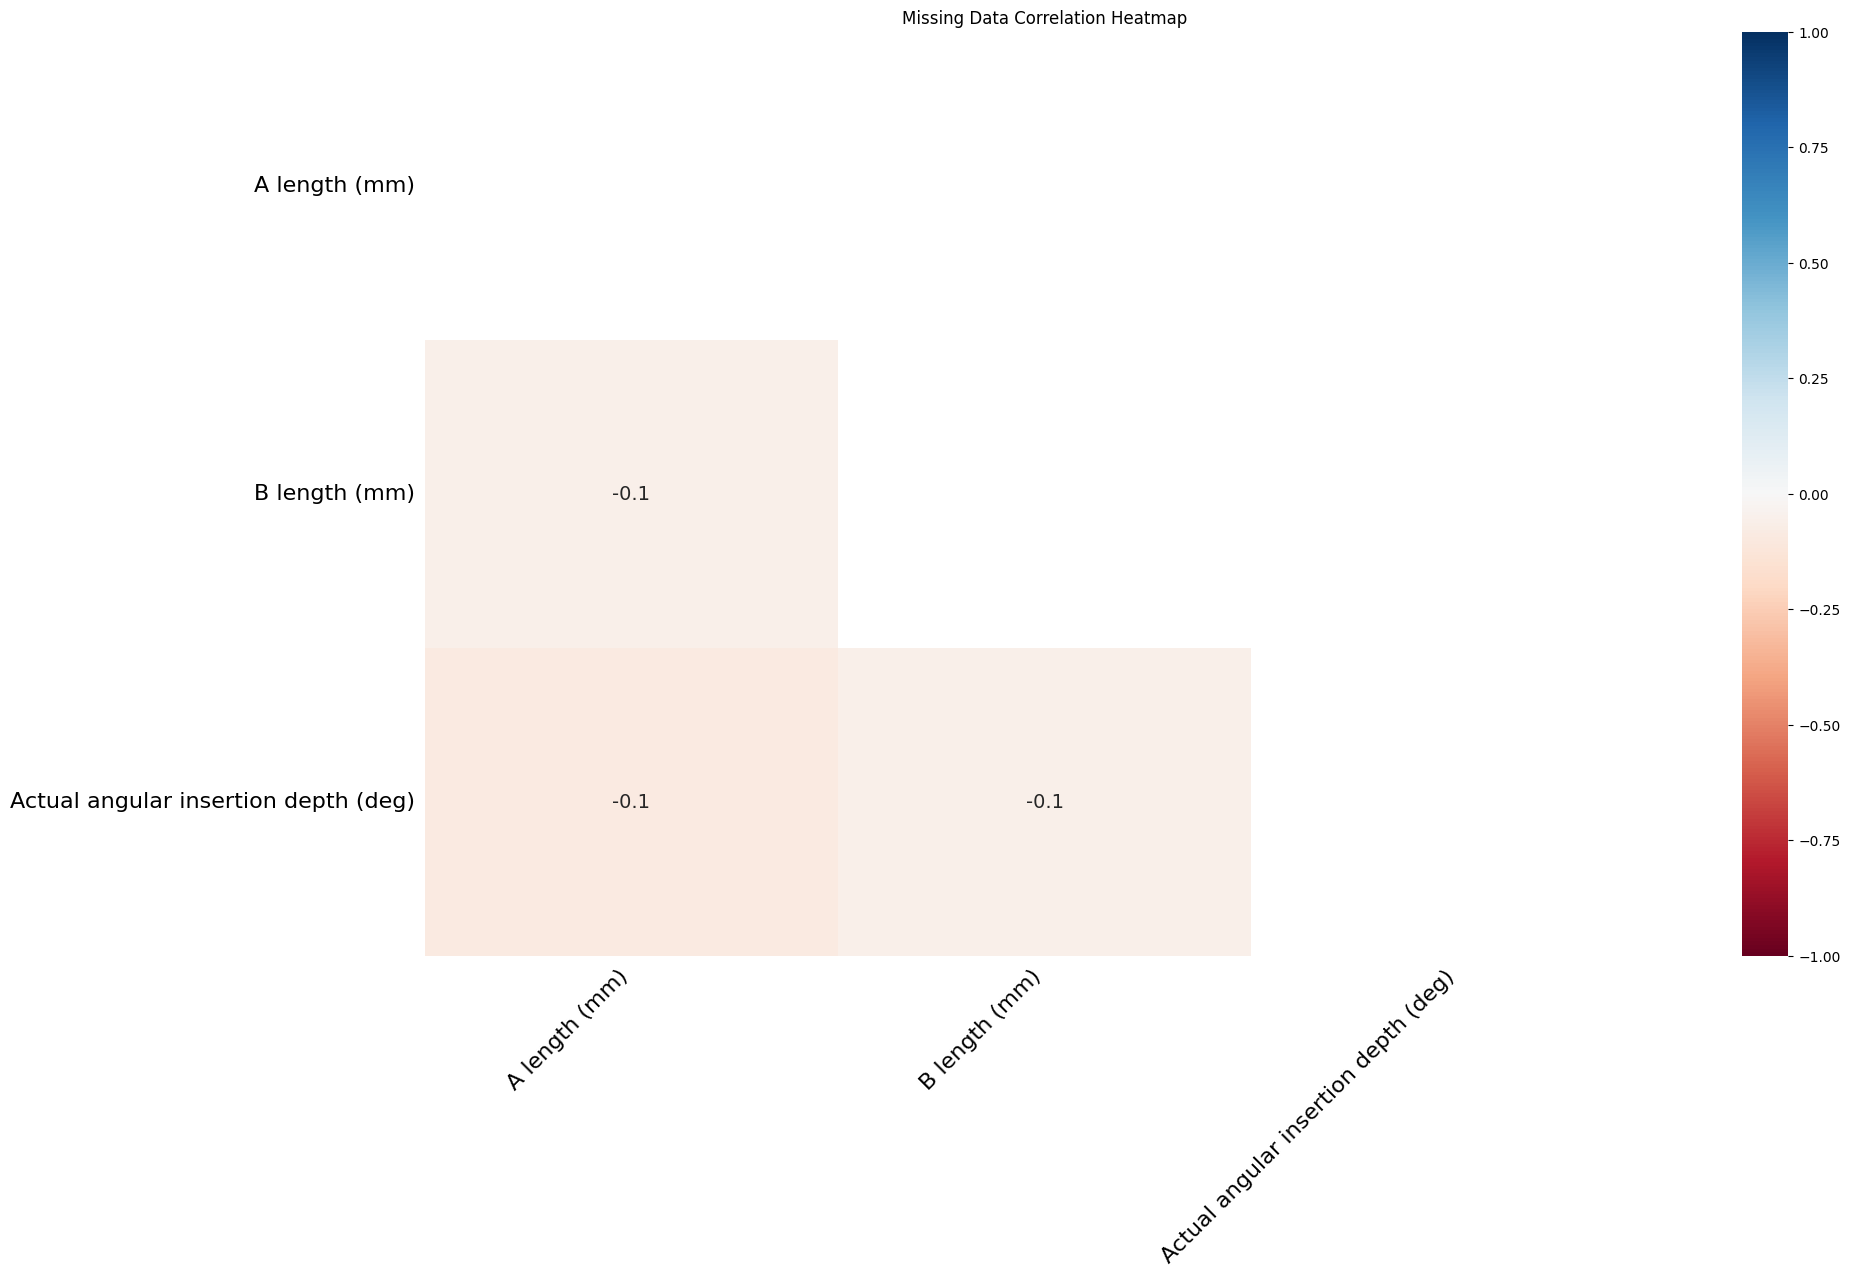

In [ ]:
# HeatMap

from google.colab import files
uploaded = files.upload()


df2 = pd.read_csv("/content/Insertion_Depth_Dataset_missing_values.csv")

# Creating the Heat map
msno.heatmap(df2)
plt.title("Missing Data Correlation Heatmap")
plt.show()

# Step Three: Imputation Methods

In [ ]:
# add Simplelmputer for the missing values to help with mean strategies
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

df_imputed_regression = df2.copy()


# Loop through each column in the dataframe to check wheater that column has missing data
#insnull() will return true for missing values and false in not
# .sum() counts the true
for target_col in df2.columns:
    if df2[target_col].isnull().sum() > 0:

       # Separates the dataset into X- predictors( Not the target) and Y- missing data (the target)
        X = df2.drop(columns=[target_col])
        y = df2[target_col]

    #Mean
    # Fill any missing values in x by replacing it witht the mean of each column
    #Compute the avg value of each column
        imputer = SimpleImputer(strategy='mean')
        #calculates the mean for each column in x then replaces any missing values with mean
        X_imputed = imputer.fit_transform(X)

        # Known Vs UnKnown To train regression model on complete rows and use it to predict the missing data
        # separates the data into missing and non missing
        #X train predictors for all complete rows
        #y.insnull() true for missing data
        # ~y.insull() true where there is no missing data
        X_train = X_imputed[~y.isnull()]
        y_train = y[~y.isnull()]
        X_test = X_imputed[y.isnull()]

        # Train regression model
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Prediction
        predicted_values = model.predict(X_test)

        # Fill in missing values
        df_imputed_regression.loc[y.isnull(), target_col] = predicted_values

print(df_imputed_mean.isnull().sum())
print(df_imputed_knn.isnull().sum())
print(df_imputed_regression.isnull().sum())



BID (mm)                                0
Cochlear scale (mm)                     0
A length (mm)                           0
B length (mm)                           0
Actual angular insertion depth (deg)    0
Array Length (mm)                       0
Array Diameter (mm)                     0
dtype: int64
BID (mm)                                0
Cochlear scale (mm)                     0
A length (mm)                           0
B length (mm)                           0
Actual angular insertion depth (deg)    0
Array Length (mm)                       0
Array Diameter (mm)                     0
dtype: int64
BID (mm)                                0
Cochlear scale (mm)                     0
A length (mm)                           0
B length (mm)                           0
Actual angular insertion depth (deg)    0
Array Length (mm)                       0
Array Diameter (mm)                     0
dtype: int64


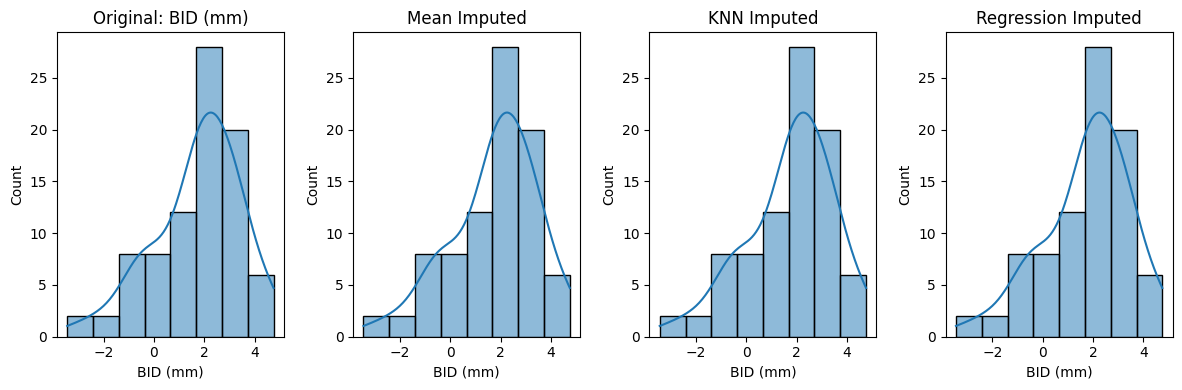

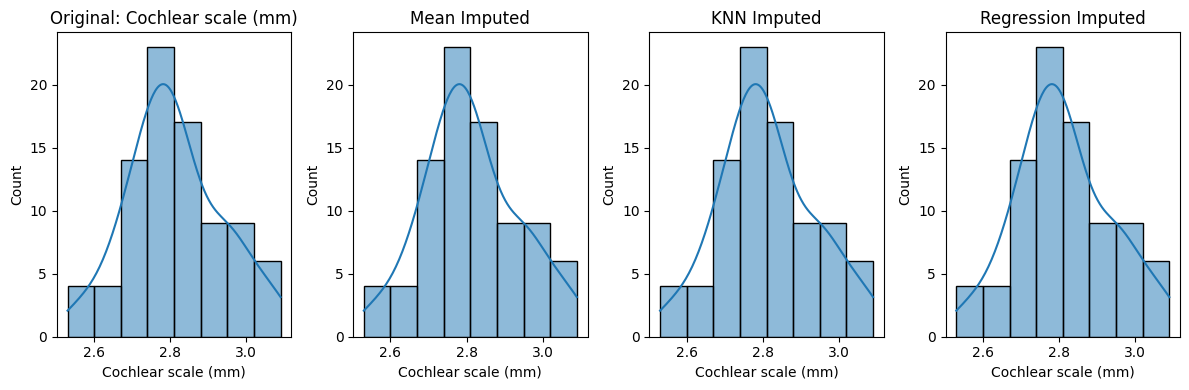

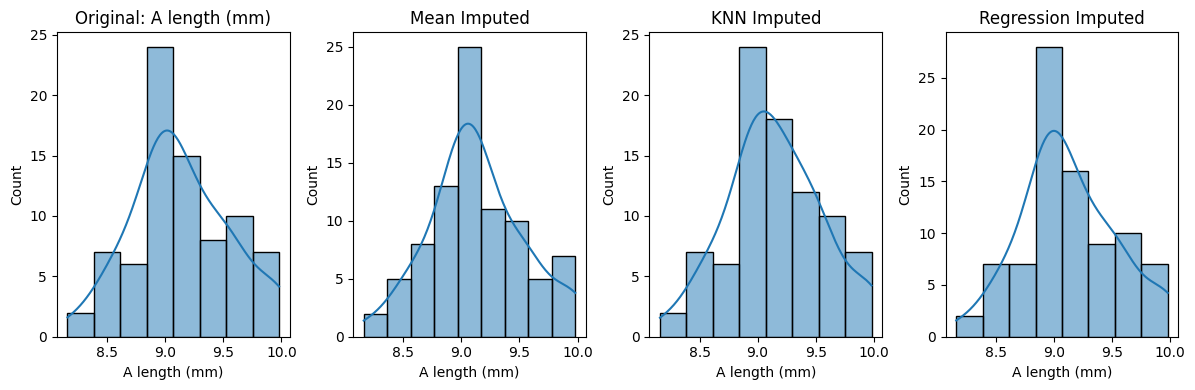

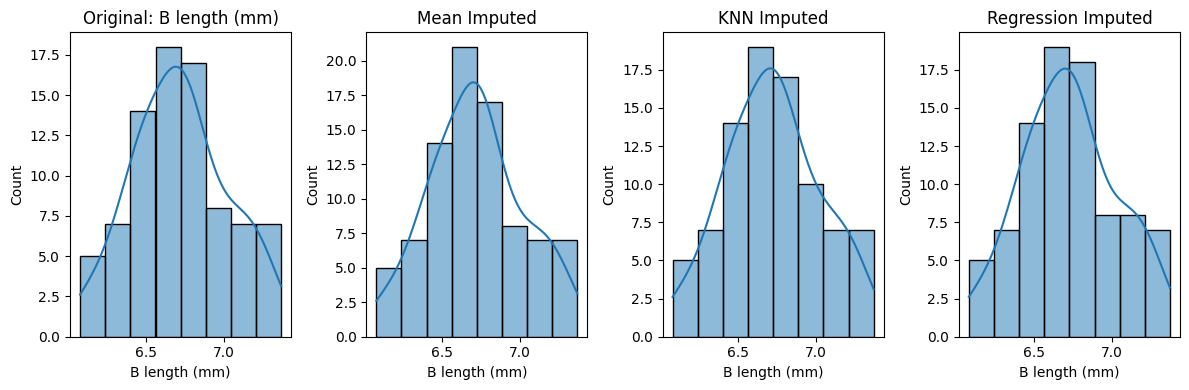

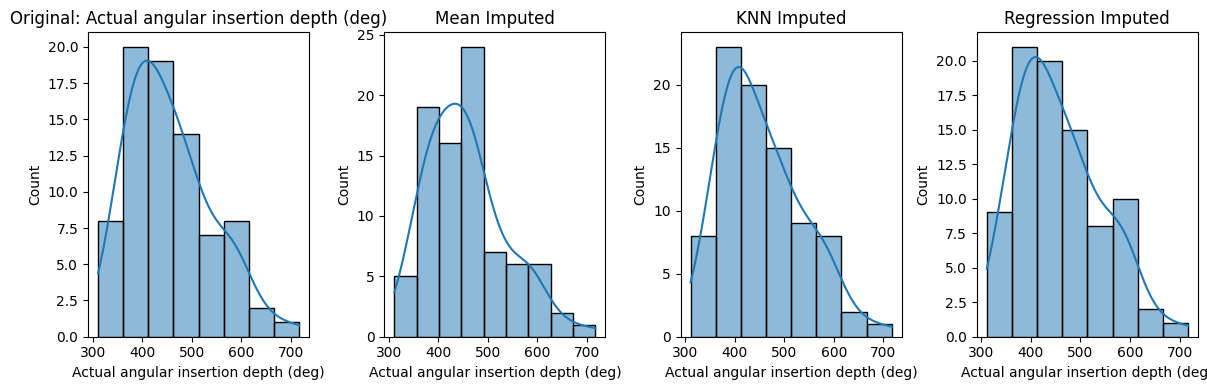

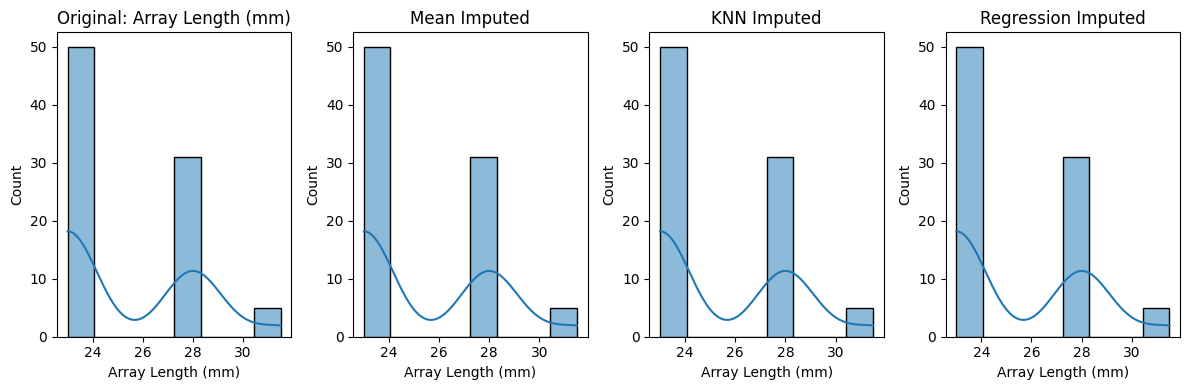

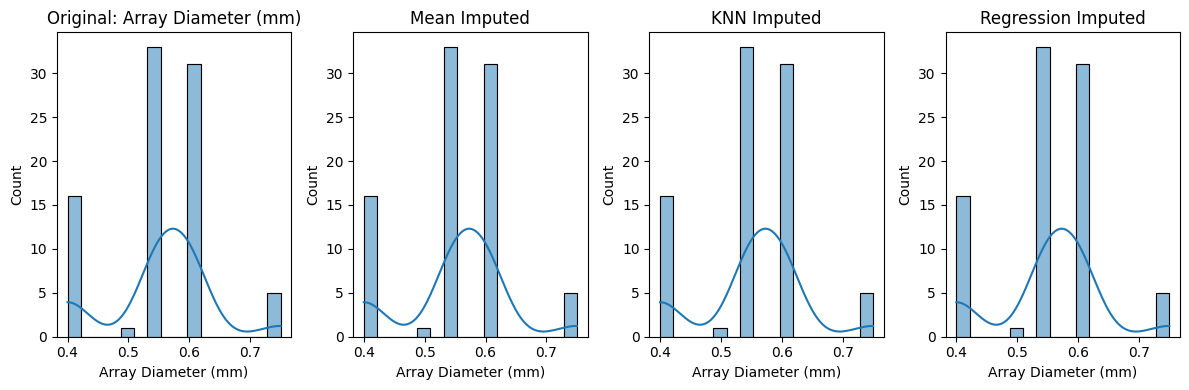

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


for col in df2.columns:
    plt.figure(figsize=(12,4))

    # Original
    plt.subplot(1,4,1)
    sns.histplot(df2[col], kde=True)
    plt.title(f"Original: {col}")

    # Mean
    plt.subplot(1,4,2)
    sns.histplot(df_imputed_mean[col], kde=True)
    plt.title("Mean Imputed")

    # KNN
    plt.subplot(1,4,3)
    sns.histplot(df_imputed_knn[col], kde=True)
    plt.title("KNN Imputed")

    # Regression
    plt.subplot(1,4,4)
    sns.histplot(df_imputed_regression[col], kde=True)
    plt.title("Regression Imputed")

    plt.tight_layout()
    plt.show()


# Step Four: Visualization and Analysis

/tmp/ipython-input-444966335.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Original", "Mean", "KNN", "Regression"])


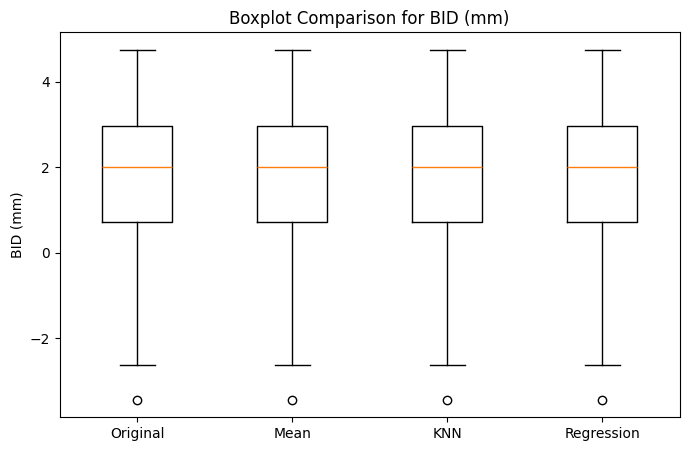

/tmp/ipython-input-444966335.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Original", "Mean", "KNN", "Regression"])


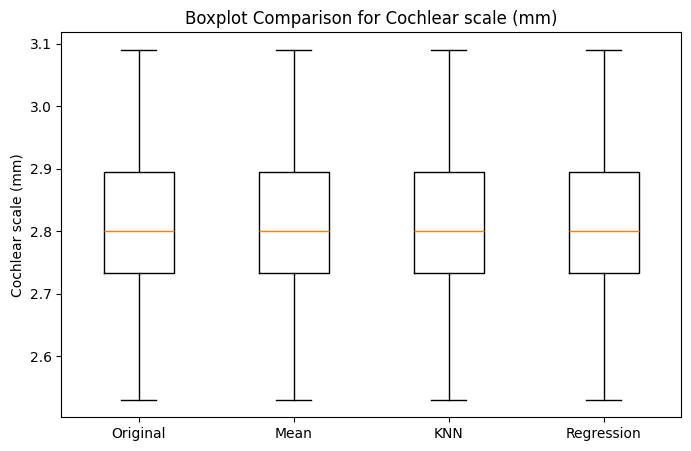

/tmp/ipython-input-444966335.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Original", "Mean", "KNN", "Regression"])


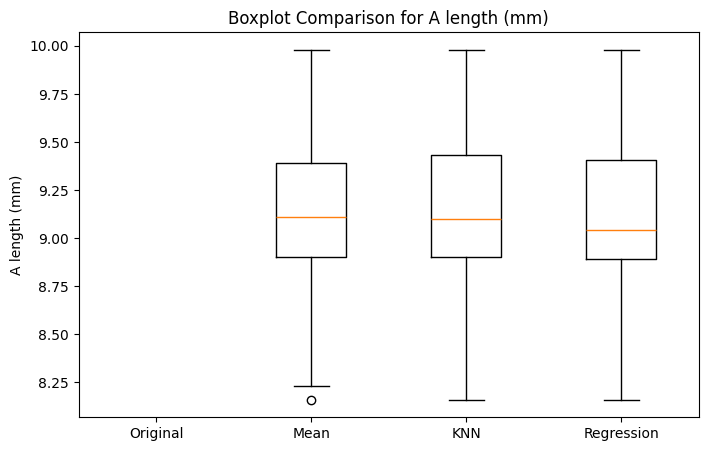

/tmp/ipython-input-444966335.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Original", "Mean", "KNN", "Regression"])


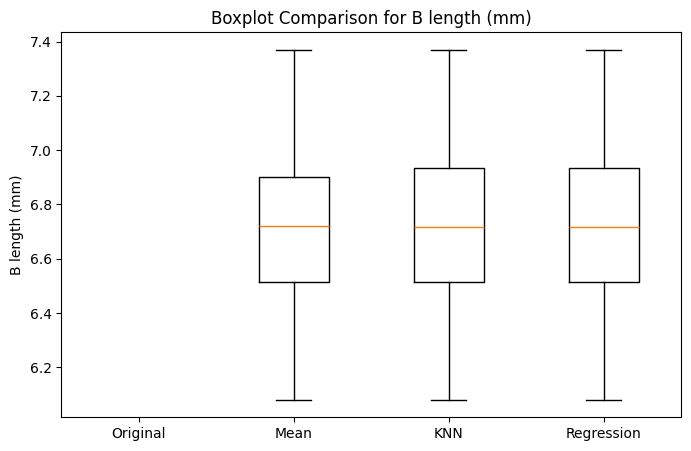

/tmp/ipython-input-444966335.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Original", "Mean", "KNN", "Regression"])


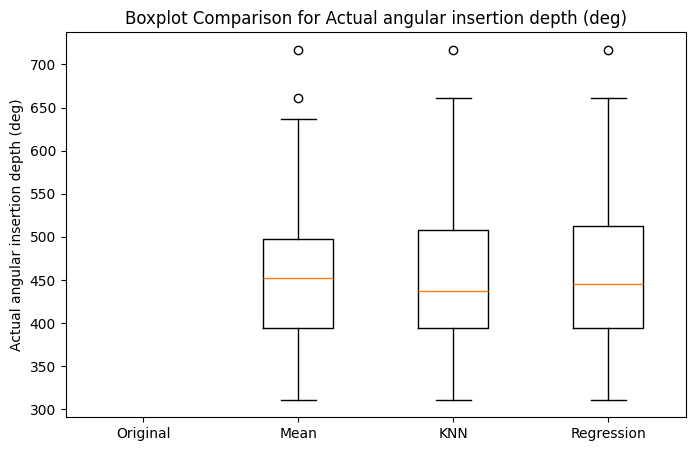

/tmp/ipython-input-444966335.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Original", "Mean", "KNN", "Regression"])


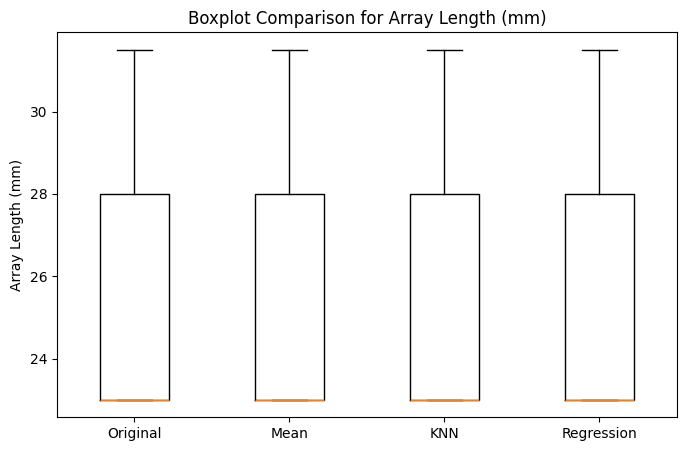

/tmp/ipython-input-444966335.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Original", "Mean", "KNN", "Regression"])


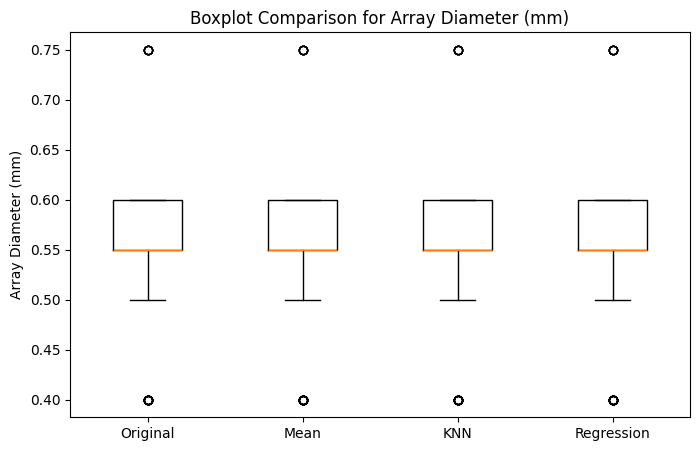

In [ ]:
for col in df2.columns:
    plt.figure(figsize=(8,5))

    data_to_plot = [
        df2[col],
        df_imputed_mean[col],
        df_imputed_knn[col],
        df_imputed_regression[col]
    ]

    plt.boxplot(data_to_plot, labels=["Original", "Mean", "KNN", "Regression"])
    plt.title(f"Boxplot Comparison for {col}")
    plt.ylabel(col)
    plt.show()
